# **1. Libraries and Dataset**

In [ ]:
!pip install -q tokenizers torch datasets transformers accelerate diffusers sentencepiece bitsandbytes
!wget -q -O Roboto-Regular.ttf https://github.com/googlefonts/roboto/raw/main/src/hinted/Roboto-Regular.ttf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.3 MB/s eta 0:00:00:00:0100:01


In [ ]:
%mkdir models
%cd models

#trained transformer
!gdown 1_Zr9UV7mU0EYGXwIjrfGiv5SLCtNjV22
#customed tokenizer
!gdown 1hsq-t_wd8rtYOkrujHnR9d9nOjtPA1oF
#finetuned gpt2
!gdown 1zrHt11PT6GYd3sQhSRgOThiOkLadTwRu
!unzip -q gpt2-finetuned.zip
!rm -rf gpt2-finetuned.zip

%ls
%cd ..

/kaggle/working/models
Downloading...
From (original): https://drive.google.com/uc?id=1_Zr9UV7mU0EYGXwIjrfGiv5SLCtNjV22
From (redirected): https://drive.google.com/uc?id=1_Zr9UV7mU0EYGXwIjrfGiv5SLCtNjV22&confirm=t&uuid=2fa22395-fa03-4296-ba39-45e2f5aad367
To: /kaggle/working/models/transformer_scratch.pth
100%|██████████████████████████████████████| 67.5M/67.5M [00:01<00:00, 50.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1hsq-t_wd8rtYOkrujHnR9d9nOjtPA1oF
To: /kaggle/working/models/custom_bpe_tokenizer.json
100%|█████████████████████████████████████████| 370k/370k [00:00<00:00, 112MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1zrHt11PT6GYd3sQhSRgOThiOkLadTwRu
From (redirected): https://drive.google.com/uc?id=1zrHt11PT6GYd3sQhSRgOThiOkLadTwRu&confirm=t&uuid=1c2e3f16-c59d-4f02-9516-247f0b7d0572
To: /kaggle/working/models/gpt2-finetuned.zip
100%|████████████████████████████████████████| 425M/425M [00:05<00:00, 72.2MB/s]
custom_bpe_tokenizer.json  gpt2-

In [ ]:
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from datasets import Dataset
from tokenizers import Tokenizer
from transformers import GPT2Tokenizer, GPT2LMHeadModel, TrainingArguments, Trainer, DataCollatorForLanguageModeling, AutoTokenizer, AutoModelForCausalLM, pipeline, BitsAndBytesConfig
from diffusers import StableDiffusionXLPipeline
from PIL import Image, ImageDraw, ImageFont, ImageOps
import re
import logging
import textwrap

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f"Using device: {device}")

dummy_data = {
    "story": [
        "<|paragraph|> Ngày xửa ngày xưa, một hiệp sĩ lên đường diệt rồng. <|paragraph|> Anh vung kiếm chém đứt xiềng xích, cứu công chúa. <|paragraph|> Họ sống hạnh phúc mãi mãi.",
        "<|paragraph|> Trong khu rừng sương mù, chú thỏ trắng đang tìm cà rốt. <|paragraph|> Sói xám xuất hiện gầm gừ. <|paragraph|> Thỏ nhanh trí trốn vào một hốc cây nhỏ."
    ] * 50
}
pd.DataFrame(dummy_data).to_csv("stories.csv", index=False)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


# **2. Text-to-Text Modules**

## **Option I: Transformer From Scratch**

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, embedding_dims, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embedding_dims, 2) * (-math.log(10000.0) / embedding_dims))
        pe = torch.zeros(1, max_len, embedding_dims)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

class TransformerLM(nn.Module):
    def __init__(self, vocab_sz, emb_dims, n_heads, hidden_dims, n_layers, dropout=0.1):
        super(TransformerLM, self).__init__()
        self.embedding = nn.Embedding(vocab_sz, emb_dims)
        self.pos_encoder = PositionalEncoding(emb_dims, dropout)

        encoder_layers = nn.TransformerEncoderLayer(
            d_model=emb_dims,
            nhead=n_heads,
            dim_feedforward=hidden_dims,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, n_layers)
        self.linear = nn.Linear(emb_dims, vocab_sz)
        self.emb_dims = emb_dims

    def forward(self, src, src_mask=None, src_key_padding_mask=None):
        src = self.embedding(src) * math.sqrt(self.emb_dims)
        src = self.pos_encoder(src)

        output = self.transformer_encoder(
            src,
            mask=src_mask,
            src_key_padding_mask=src_key_padding_mask
        )
        return self.linear(output)

In [ ]:
class TransformerManager:
    def __init__(self, model_path="./models/transformer_scratch.pth", tokenizer_path="./models/custom_bpe_tokenizer.json"):
        self.tokenizer = Tokenizer.from_file(tokenizer_path)
        self.vocab_size = self.tokenizer.get_vocab_size()

        self.eos_token_id = self.tokenizer.token_to_id("<|eos|>")

        self.model = TransformerLM(
            vocab_sz=self.vocab_size,
            emb_dims=512,
            n_heads=8,
            hidden_dims=1024,
            n_layers=4,
            dropout=0.1
        ).to(device)
        self.model_path = model_path

    def load_model(self):
        if os.path.exists(self.model_path):
            self.model.load_state_dict(torch.load(self.model_path, map_location=device))
            logger.info("Transformer Scratch model loaded successfully!")
        else:
            logger.warning("Transformer Scratch model not found, initializing randomly.")
        self.model.eval()

    def generate(self, prompt_text, max_length=100, temperature=0.7):
        self.model.eval()
        self.tokenizer.no_padding()
        self.tokenizer.no_truncation()

        prompt_text = f"<|bos|>\n<|summary|> {prompt_text}\n"

        input_encoded = self.tokenizer.encode(prompt_text)
        generated_ids = input_encoded.ids.copy()

        for _ in range(max_length):
            input_tensor = torch.tensor([generated_ids], dtype=torch.long).to(device)
            seq_len = input_tensor.size(1)
            causal_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(device)

            with torch.no_grad():
                outputs = self.model(input_tensor, src_mask=causal_mask)

            last_token_logits = outputs[0, -1, :] / temperature
            probs = F.softmax(last_token_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1).item()
            generated_ids.append(next_token)

            if next_token == self.eos_token_id:
                break

        final_text = self.tokenizer.decode(generated_ids, skip_special_tokens=False)
        return final_text

## **Option II: GPT-2 (Fine-Tuning concept)**

In [ ]:
class GPT2Manager:
    def __init__(self, model_name="gpt2", save_dir="./models/gpt2-finetuned"):
        self.model_name = model_name
        self.save_dir = save_dir
        self.tokenizer = GPT2Tokenizer.from_pretrained(model_name)
        self.tokenizer.pad_token = self.tokenizer.eos_token
        self.model = None

    def fine_tune(self, csv_path):
        logger.info("Starting GPT-2 fine-tuning...")
        df = pd.read_csv(csv_path)
        hf_dataset = Dataset.from_pandas(df)

        def tokenize_function(examples):
            return self.tokenizer(
                examples["story"],
                truncation=True,
                padding="max_length",
                max_length=128
            )

        tokenized_datasets = hf_dataset.map(tokenize_function, batched=True)
        model = GPT2LMHeadModel.from_pretrained(self.model_name).to(device)
        data_collator = DataCollatorForLanguageModeling(tokenizer=self.tokenizer, mlm=False)

        training_args = TrainingArguments(
            output_dir=self.save_dir,
            overwrite_output_dir=True,
            num_train_epochs=3,
            per_device_train_batch_size=4,
            save_steps=100,
            logging_steps=10,
            report_to="none"
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=tokenized_datasets,
            data_collator=data_collator
        )
        trainer.train()
        trainer.save_model(self.save_dir)
        self.tokenizer.save_pretrained(self.save_dir)
        logger.info(f"GPT-2 fine-tuned model saved at: {self.save_dir}")

    def load_model(self):
        load_path = self.save_dir if os.path.exists(self.save_dir) else self.model_name
        logger.info(f"Loading GPT-2 model from: {load_path}")
        self.tokenizer = GPT2Tokenizer.from_pretrained(load_path)
        self.model = GPT2LMHeadModel.from_pretrained(load_path).to(device)
        self.model.eval()

    def generate(self, prompt_text, max_new_tokens=1024, temperature=0.7, top_k=50, top_p=0.95):
        if self.model is None:
            self.load_model()

        prompt = f"<|bos|>\n<|summary|> {prompt_text}\n"
        inputs = self.tokenizer(prompt_text, return_tensors='pt').to(device)

        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                top_k=top_k,
                top_p=top_p,
                temperature=temperature,
                pad_token_id=self.tokenizer.pad_token_id,
                eos_token_id=self.tokenizer.eos_token_id
            )

        decoded_text = self.tokenizer.decode(outputs[0], skip_special_tokens=True)
        if "<|paragraph|>" not in decoded_text:
            decoded_text = f"<|paragraph|> {decoded_text} <|paragraph|> Một diễn biến bất ngờ xảy ra tiếp theo."
        return decoded_text

## **Option III: Large Language Models - LLama3**

In [ ]:
class LLMClient:
    def __init__(self, model_id="meta-llama/Meta-Llama-3-8B-Instruct", hf_token=None):
        self.model_id = model_id
        self.hf_token = hf_token
        self.model = None
        self.generator = None
        self.tokenizer = None

    def load_model(self):

        if self.model is not None:
            logger.info(f"LLM {self.model_id} already loaded. Skipping.")
            return

        logger.info(f"Loading LLM {self.model_id}...")
        self.tokenizer = AutoTokenizer.from_pretrained(
            self.model_id,
            token=self.hf_token
        )
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        llama3_template = "{% set loop_messages = messages %}{% for message in loop_messages %}{% if message['role'] == 'system' %}{{ '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\n' + message['content'] + '<|eot_id|>' }}{% elif message['role'] == 'user' %}{{ '<|start_header_id|>user<|end_header_id|>\n\n' + message['content'] + '<|eot_id|>' }}{% elif message['role'] == 'assistant' %}{{ '<|start_header_id|>assistant<|end_header_id|>\n\n' + message['content'] + '<|eot_id|>' }}{% endif %}{% endfor %}{% if add_generation_prompt %}{{ '<|start_header_id|>assistant<|end_header_id|>\n\n' }}{% endif %}"
        self.tokenizer.chat_template = llama3_template

        bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)
        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_id,
            device_map="auto",
            quantization_config=bnb_config,
            token=self.hf_token,
            cache_dir="./models/"
        )
        self.generator = pipeline(
            "text-generation",
            model=self.model,
            tokenizer=self.tokenizer
        )
        logger.info("LLM loaded successfully.")

    def generate(self, prompt, max_new_tokens=512):
        if self.generator is None:
            self.load_model()

        messages = [
            {"role": "system", "content": "You are a helpful and precise assistant."},
            {"role": "user", "content": prompt}
        ]

        prompt_text = self.tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )
        outputs = self.generator(
            prompt_text,
            max_new_tokens=max_new_tokens,
            return_full_text=False,
            temperature=0.7,
            do_sample=True,
            pad_token_id=self.tokenizer.eos_token_id
        )
        return outputs[0]['generated_text'].strip()

In [ ]:
class StoryGenerator:
    def __init__(self, llm_client, option=3, hf_token=None):
        self.option = option
        self.model = self._initialize_model(llm_client)

    def _initialize_model(self, llm_client):
        if self.option == 1:
            return TransformerManager()
        elif self.option == 2:
            return GPT2Manager()
        elif self.option == 3:
            logger.info("LLaMA 3 is managed globally. Skipping local load.")
            return llm_client
        else:
            raise ValueError("Invalid option. Choose 1, 2, or 3.")

    def load(self):
        logger.info(f"\n--- Initializing Text Model (Option {self.option}) ---")
        self.model.load_model()

    def create_story_prompt(self, user_story: str) -> str:
        return f"""Hãy mở rộng đoạn tóm tắt dưới đây thành một câu chuyện ngụ ngôn.
Tóm tắt câu chuyện:
{user_story}

Bạn phải định dạng đầu ra chính xác như sau, nội dung từng đoạn phải bắt đầu bằng một thẻ <|paragraph|>:
<|paragraph|> [Nội dung đoạn 1] <|paragraph|> [Nội dung đoạn 2]

Chú ý:
- Không sinh thêm thẻ nào ngoài các thẻ <|paragraph|> đã được quy định.
- Phong cách kể chuyện ngụ ngôn, không cần sinh tên cụ thể cho nhân vật.
- Nội dung sinh ra là Tiếng Việt, giới hạn dưới 20 từ mỗi đoạn.
"""

    def gen_story_structured(self, user_story: str, use_custom_prompt: bool = True, **kwargs) -> str:
        logger.info(f"\nProcessing prompt...")

        if self.option == 3 and use_custom_prompt:
            final_prompt = self.create_story_prompt(user_story)
            logger.info("Custom Prompt for LLaMA 3 enabled.")
        else:
            final_prompt = user_story
            logger.info("Using original User Prompt (for smaller models).")

        return self.model.generate(final_prompt, **kwargs)

# **3. Text-to-Image Module: Diffusion**

In [ ]:
class ImagePromptGenerator:
    def __init__(self, llm_client=None):
        self.llm_client = llm_client

    def parse_paragraphs(self, raw_text: str):
        paragraphs = []
        pattern = r"<\|paragraph\|>(.*?)(?=<\|paragraph\|>|<\|eos\|>|$)"
        for match in re.finditer(pattern, raw_text, re.DOTALL):
            content = match.group(1).strip()
            if content: paragraphs.append(content)
        return paragraphs

    def create_visual_prompt(self, paragraph: str, full_story: str, style: str = "whimsical fable book illustration, highly detailed, vibrant colors, fantasy art style"):
        if self.llm_client is None:
            logger.warning("LLM Client does not exists. Return fallback prompt.")
            return f"{paragraph}, {style}"

        translation_prompt = f"""You are an expert art director. Given the full context of a Vietnamese story, translate the specific paragraph into a highly short descriptive English image prompt.
Maintain visual consistency of characters, objects, and environments based on the overall story.
Focus only on the visual elements (characters, actions, environment) of the specific paragraph.
Do NOT include any explanations or conversational text. Return ONLY the English translation, under 50 words.

Full Story Context: "{full_story}"

Specific Paragraph to visualize: "{paragraph}"

English Image Prompt:"""
        english_translation = self.llm_client.generate(translation_prompt, max_new_tokens=100)
        english_translation = english_translation.strip(' "\'\n')

        final_prompt = f"{english_translation}, {style}"
        return final_prompt

In [ ]:
class DiffusionClient:
    def __init__(self, huggingface_path="Lykon/dreamshaper-xl-v2-turbo"):
        self.huggingface_path = huggingface_path
        self.pipeline = None

    def load_model(self):
        logger.info("Loading SDXL model...")
        self.pipeline = StableDiffusionXLPipeline.from_pretrained(
            self.huggingface_path,
            torch_dtype=torch.float16,
            variant="fp16",
            use_safetensors=True
        )
        self.pipeline.enable_model_cpu_offload()
        self.pipeline.enable_vae_slicing()
        self.pipeline.enable_vae_tiling()

    def add_caption_box(self, image, text):
        img_with_border = ImageOps.expand(image, border=15, fill="black")
        img_copy = img_with_border.convert("RGBA")
        overlay = Image.new("RGBA", img_copy.size, (255, 255, 255, 0))
        draw = ImageDraw.Draw(overlay)

        try:
            font = ImageFont.truetype("Roboto-Regular.ttf", 32)
        except:
            font = ImageFont.load_default()

        wrapped_text = textwrap.wrap(text, width=55)
        line_height = 40
        text_total_height = len(wrapped_text) * line_height

        box_bottom = img_copy.size[1] - 30
        box_top = box_bottom - text_total_height - 30
        draw.rectangle(
            [(30, box_top), (img_copy.size[0]-30, box_bottom)],
            fill=(255, 255, 255, 235),
            outline=(0, 0, 0, 255),
            width=6
        )

        y_text = box_top + 15
        for line in wrapped_text:
            draw.text((45, y_text), line, font=font, fill="black")
            y_text += line_height

        return Image.alpha_composite(img_copy, overlay).convert("RGB")

    def gen_image(self, prompt, negative_prompt=""):
        if self.pipeline is None:
            return None
        return self.pipeline(
            prompt=prompt,
            negative_prompt=negative_prompt,
            num_inference_steps=5,
            guidance_scale=2.0
        ).images[0]

# **4. Run Pipeline**

In [ ]:
from google.colab import userdata
hf_token = userdata.get('HUGGINGFACEHUB_API_TOKEN')

model_index.json:   0%|          | 0.00/671 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

...

 --- Scene 2 ---
Caption: Quạ thử thấy gì , nhưng khi cố gắng vươn cổ bình quá nhỏ nên đã nhặt từng viên sỏi vào chiếc bình khiến mực nước và lượng nước dâng lên và lượng nước đã nhặt từng viên sỏi thả vào bình khiến mực nước và dâng lên khiến mực nước .
Image Prompt: A clever crow, struggling to reach a tall water jug, carefully drops pebbles into it, slowly raising the water level, as the crow tries to quench its thirst, with a determined gaze., whimsical fable book illustration, highly detailed, vibrant colors, fantasy art style



  0%|          | 0/5 [00:00<?, ?it/s]

Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 --- Scene 3 ---
Caption: Quạ bình để uống được cơn khát và dâng lên và
Image Prompt: A thirsty crow perched on a tall ceramic water jug, dropping small stones into it to raise the water level, finally able to quench its thirst., whimsical fable book illustration, highly detailed, vibrant colors, fantasy art style



  0%|          | 0/5 [00:00<?, ?it/s]

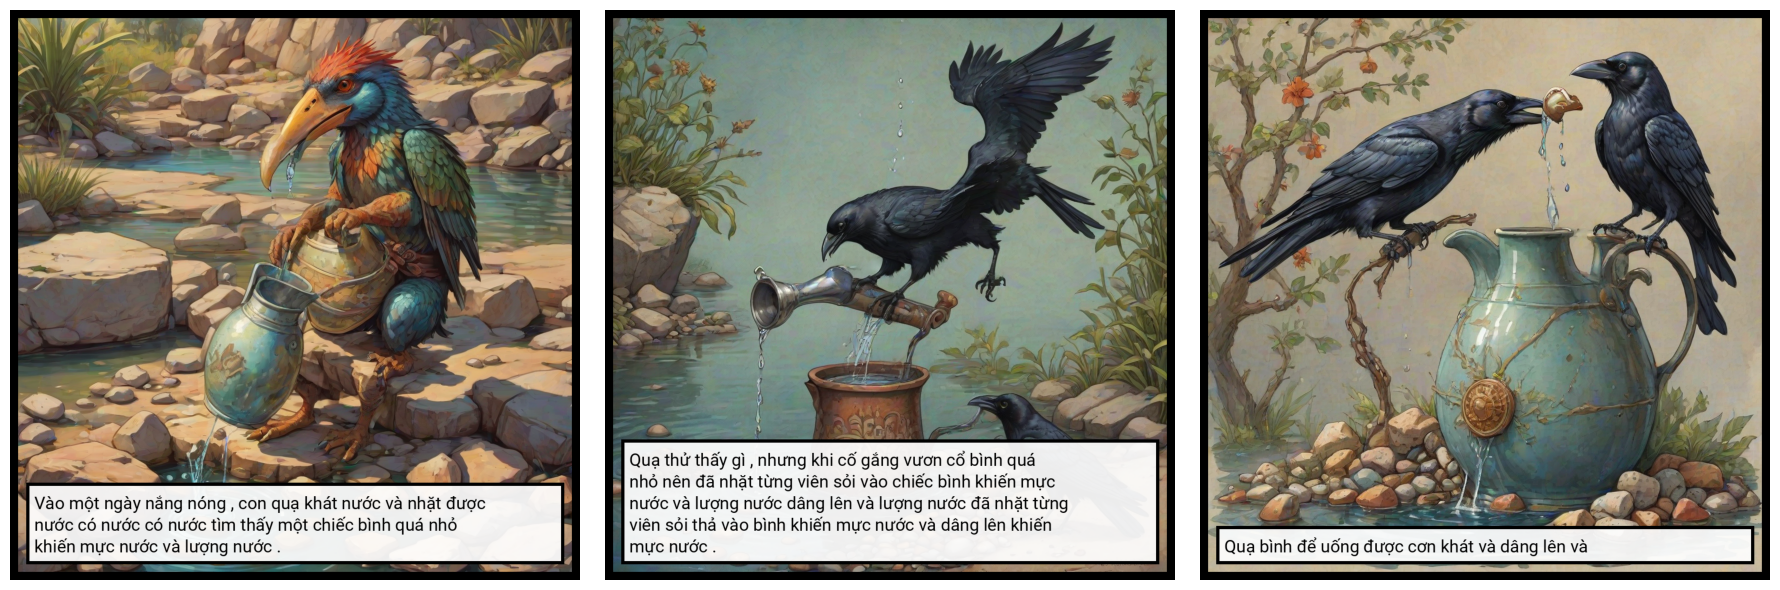

Cleaning GPU VRAM...

----------------------------------------------------------------------
Running Option: 2: GPT-2
----------------------------------------------------------------------


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...


 Generated Texts: 
<|paragraph|> Một con quạ khát nước tìm thấy một bình nước nhưng cổ bình quá cao. Quạ thông minh đã gắp từng hòn sỏi bỏ vào bình để nước dâng lên và uống được.
 Một con quạ sống trên bình nước đã tìm thấy một bình nước và phát hiện ra nó nằm trong bình. Nó không thể dâng lên, nhưng vẫn cố gắng tìm thấy bình nước và mang về cho anh ta.
 Thấy con quạ hy sinh sự giúp đỡ và hy sinh đầy bình nước, anh ta đã nhờ nó tìm thấy một hòn đá quý giá. Nó đã tìm thấy bình nước từ bên trong và nhờ nó giúp đỡ anh ta làm việc trong hang đá.
 Khi đến hang đá, con quạ thấy một bình nước và nhìn thấy nó nằm trên bình nước, nhưng anh ta vẫn cố gắng tìm thấy bình nước từ bên trong. Tuy nhiên, anh ta vẫn kiên quyết không dâng lên bình, chỉ cần đến khi <|paragraph|> Một diễn biến bất ngờ xảy ra tiếp theo.
--------------------------------------------------
 --- Scene 1 ---
Caption: Một con quạ khát nước tìm thấy một bình nước nhưng cổ bình quá cao. Quạ thông minh đã gắp từng hòn sỏi bỏ vào b

  0%|          | 0/5 [00:00<?, ?it/s]

Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 --- Scene 2 ---
Caption: Một diễn biến bất ngờ xảy ra tiếp theo.
Image Prompt: A startled crow perched on a dusty well's edge, tiny rocks scattered around, and a faint mist rising from the water's surface, as the sun sets over a worn, stone village., whimsical fable book illustration, highly detailed, vibrant colors, fantasy art style



  0%|          | 0/5 [00:00<?, ?it/s]

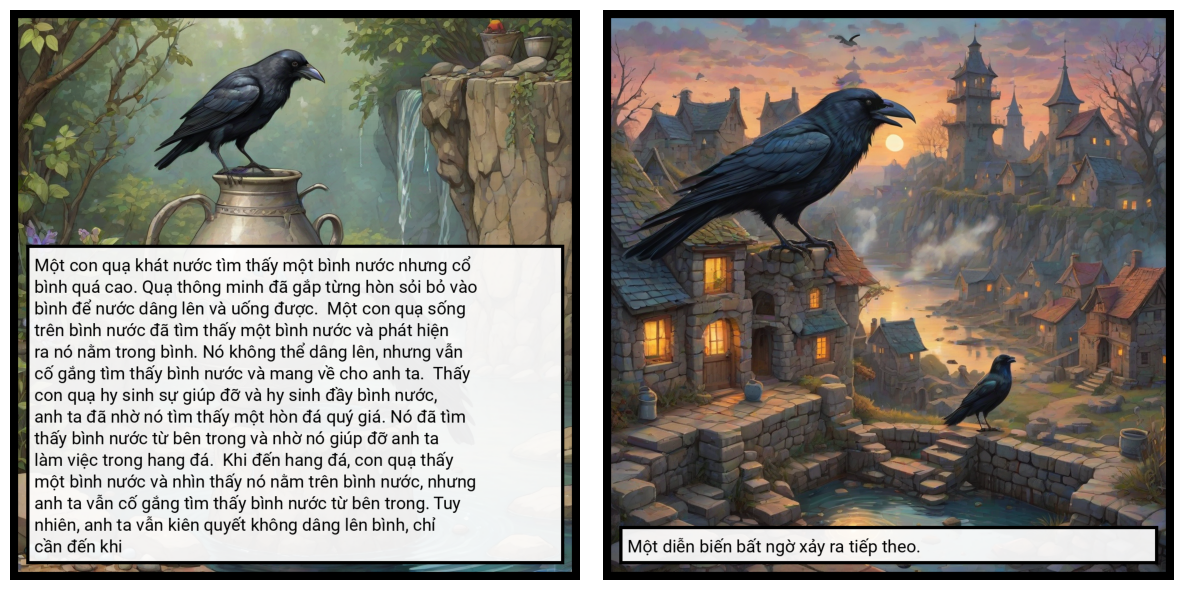

Cleaning GPU VRAM...


Both `max_new_tokens` (=400) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



----------------------------------------------------------------------
Running Option: 3: LLaMA 3
----------------------------------------------------------------------


Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



 Generated Texts: 
<|paragraph|> Trong một khu rừng xanh, một con quạ khát nước tìm thấy một bình nước. Tuy nhiên, cổ bình quá cao, nước không thể uống được.

<|paragraph|> Con quạ khát nước ngâm ngưởng, không biết làm thế nào để giải quyết vấn đề này. Vừa ngưỡng, vừa nghĩ, con quạ quyết định gắp từng hòn sỏi bỏ vào bình để nước dâng lên.

<|paragraph|> Con quạ gắp sỏi một hòn, hai hòn, ba hòn... và cứ thế, nước trong bình dâng lên, dâng lên. Con quạ rất hân hạnh, ngắm nhìn nước trong bình, ngắm nhìn nước trong bình.

<|paragraph|> Cuối cùng, con quạ đã có thể uống nước được. Con quạ ngỡ ngàng, ngất ngưỡng, ngắm nhìn nước trong bình, ngắm nhìn nước trong bình. Con quạ hiểu rằng, dù khó khăn, nhưng với sự khôn ngoan và quyết tâm, con quạ đã tìm thấy giải pháp. Con quạ cảm thấy rất hân hạnh, rất tự hào.
--------------------------------------------------
 --- Scene 1 ---
Caption: Trong một khu rừng xanh, một con quạ khát nước tìm thấy một bình nước. Tuy nhiên, cổ bình quá cao, nước không

...

 --- Scene 3 ---
Caption: Con quạ gắp sỏi một hòn, hai hòn, ba hòn... và cứ thế, nước trong bình dâng lên, dâng lên. Con quạ rất hân hạnh, ngắm nhìn nước trong bình, ngắm nhìn nước trong bình.
Image Prompt: A clever crow grasps one stone, then two, then three, and continues, as the water level rises in the tall jug. The crow beams with joy, admiring the water's steady ascent, its gaze fixed on the jug's rim., whimsical fable book illustration, highly detailed, vibrant colors, fantasy art style



  0%|          | 0/5 [00:00<?, ?it/s]

Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 --- Scene 4 ---
Caption: Cuối cùng, con quạ đã có thể uống nước được. Con quạ ngỡ ngàng, ngất ngưỡng, ngắm nhìn nước trong bình, ngắm nhìn nước trong bình. Con quạ hiểu rằng, dù khó khăn, nhưng với sự khôn ngoan và quyết tâm, con quạ đã tìm thấy giải pháp. Con quạ cảm thấy rất hân hạnh, rất tự hào.
Image Prompt: A thirsty crow perched on a tall jug, stones piled around it, water rising to the edge. The crow gazes in awe, admiring the water's clarity, its beak tilting upwards in triumph., whimsical fable book illustration, highly detailed, vibrant colors, fantasy art style



  0%|          | 0/5 [00:00<?, ?it/s]

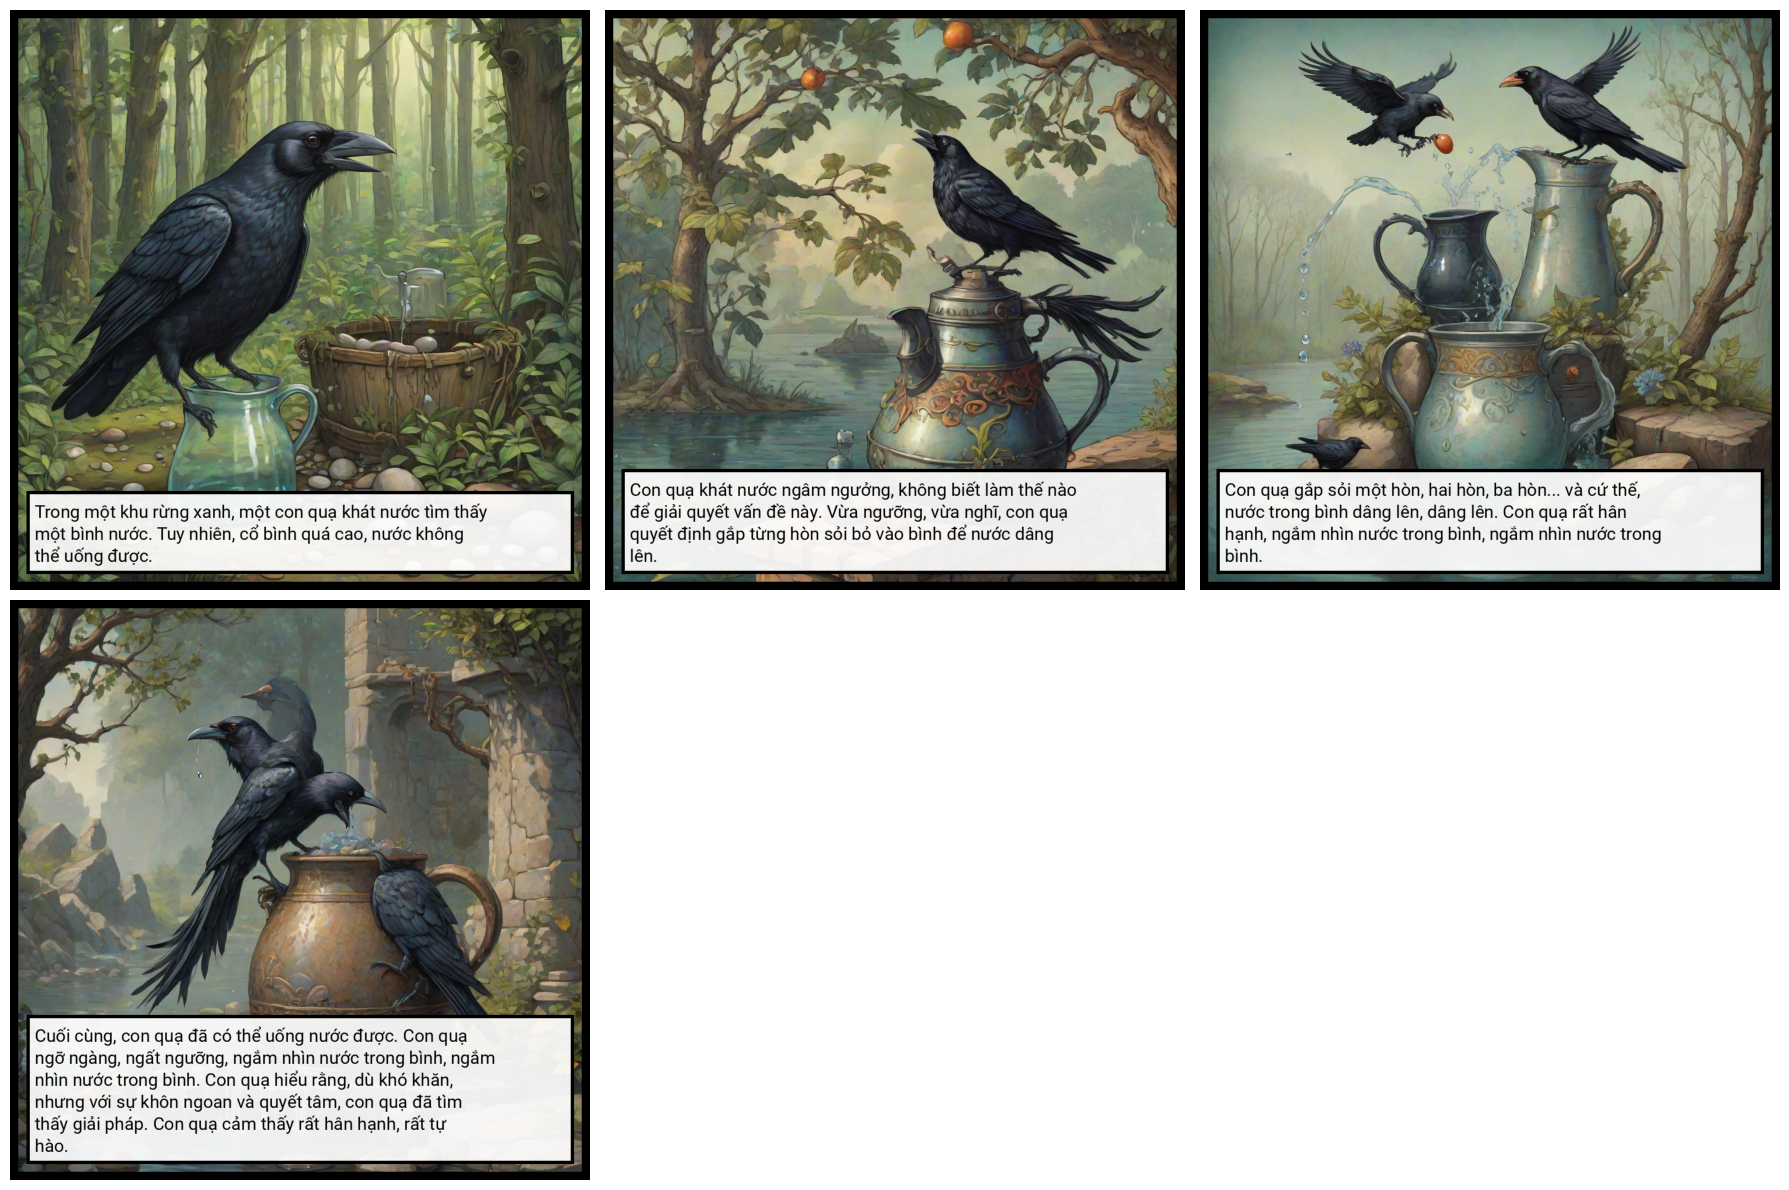

Cleaning GPU VRAM...


In [ ]:
import gc
import torch
import math
import matplotlib.pyplot as plt
from IPython.display import display

user_story = "Một con quạ khát nước tìm thấy một bình nước nhưng cổ bình quá cao. Quạ thông minh đã gắp từng hòn sỏi bỏ vào bình để nước dâng lên và uống được."

llm = LLMClient(hf_token=hf_token)

prompt_gen = ImagePromptGenerator(llm)
diff_client = DiffusionClient()
diff_client.load_model()

for opt in [1, 2, 3]:
    print("\n" + "-"*70)
    print(f"Running Option: {opt}: " +
          ("Transformer Scratch" if opt == 1 else "GPT-2" if opt == 2 else "LLaMA 3"))
    print("-"*70)

    # 1. Load model
    story_gen = StoryGenerator(llm_client = llm, option=opt)
    story_gen.load()

    # 2. Generate Text
    if opt == 1:
        story_text = story_gen.gen_story_structured(
            user_story,
            use_custom_prompt=False,
            max_length=100
        )
    elif opt == 2:
        story_text = story_gen.gen_story_structured(
            user_story,
            use_custom_prompt=False,
            max_new_tokens=150
        )
    else:
        story_text = story_gen.gen_story_structured(
            user_story,
            use_custom_prompt=True,
            max_new_tokens=400
        )

    print("\n Generated Texts: ")
    print(story_text)
    print("-" * 50)

    # 3. Generate Image prompts & Images
    paragraphs = prompt_gen.parse_paragraphs(story_text)

    if not paragraphs:
        print("Error format <|paragraph|>... using fallback.")
        paragraphs = [p.strip() for p in story_text.split('.') if len(p.strip()) > 10][:2]

    generated_images = []

    for i, para in enumerate(paragraphs):
        visual_prompt = prompt_gen.create_visual_prompt(
            paragraph=para,
            full_story=user_story
        )

        print(f" --- Scene {i+1} ---")
        print(f"Caption: {para}")
        print(f"Image Prompt: {visual_prompt}\n")

        if diff_client.pipeline is not None:
            img = diff_client.gen_image(
                visual_prompt
            )
            if img is not None:
                final_img = diff_client.add_caption_box(
                    img,
                    para
                )
                generated_images.append(final_img)

    # 4. Display images
    n_images = len(generated_images)
    if n_images > 0:
        cols = min(3, max(1, n_images))
        rows = math.ceil(n_images / cols)

        fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 6 * rows))

        if n_images == 1:
            axes = [axes]
        else:
            axes = axes.flatten()

        for idx, ax in enumerate(axes):
            if idx < n_images:
                ax.imshow(generated_images[idx])
                ax.axis('off')
            else:
                ax.axis('off')

        plt.tight_layout()
        plt.show()

    # 4. Clean VRAM
    print(f"Cleaning GPU VRAM...")
    if opt == 1 or opt == 2:
        if hasattr(story_gen.model, 'model') and story_gen.model.model is not None:
            del story_gen.model.model

    del story_gen
    gc.collect()
    torch.cuda.empty_cache()